# YOLO para clasificación y segmentación de residuos

Este notebook desarrolla un ejercicio usando **YOLO** para dos tareas diferentes:

1. **Clasificación:** el modelo observa una imagen completa y responde qué tipo de residuo aparece principalmente.
2. **Segmentación:** el modelo localiza el residuo dentro de la imagen y dibuja una máscara sobre su forma.

La idea es trabajar con datasets gratuitos:

- **TrashNet** para clasificación.
- **TACO — Trash Annotations in Context** para segmentación.

>Las clases propuestas son: `plastico`, `papel_carton`, `metal`, `vidrio` y `basura_general`.

# Antes de empezar: instrucciones generales

1. Notebook para utilizarse en **Google Colab** o en **Jupyter Notebook**
2. En Google Colab, activar GPU:

   **Entorno de ejecución → Cambiar tipo de entorno de ejecución → GPU**

3. Ejecutar las celdas en orden, de arriba hacia abajo.
4. Primero descargar y preparar los datasets y luego realizar el entrenamiento.
5. Si el entrenamiento tarda mucho, disminuir el número de épocas en la sección de configuración.


Al final se tendrán dos modelos entrenados:

- Un modelo que **clasifica** imágenes de residuos.
- Un modelo que **segmenta** residuos dentro de una imagen.

# 1. Instalación de librerías

Primero instala las librerías necesarias para usar YOLO y manejar los archivos del dataset.

Ejecuta la siguiente celda una sola vez al inicio del notebook.



In [2]:
!pip -q install ultralytics pyyaml tqdm

import os
import json
import random
import shutil
import zipfile
from pathlib import Path
from collections import Counter, defaultdict

import yaml
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

from ultralytics import YOLO

print('Librerías instaladas y cargadas correctamente.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 69.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Librerías instaladas y cargadas correctamente.


# 2. Configuración general del proyecto

## ¿Qué hace esta sección?

Define las carpetas donde se guardarán los datasets, los modelos base de YOLO y algunos parámetros de entrenamiento.

## Explicación

- `EPOCHS_CLS` controla cuántas veces entrenará el modelo de clasificación.
- `EPOCHS_SEG` controla cuántas veces entrenará el modelo de segmentación.
- `MAX_IMAGES_SEG` limita la cantidad de imágenes de TACO para que la práctica no sea tan pesada.

## Recomendación

Para una prueba rápida, puedes dejar los valores como están. Para un proyecto más completo, puedes aumentar las épocas y usar más imágenes.

In [3]:
BASE_DIR = Path('/content/yolo_residuos')
BASE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
random.seed(SEED)

# Modelos base de YOLO.
# El modelo terminado en -cls sirve para clasificación.
# El modelo terminado en -seg sirve para segmentación.
MODEL_CLS = 'yolo11n-cls.pt'
MODEL_SEG = 'yolo11n-seg.pt'

# Épocas de entrenamiento.
# Si tu computadora o Colab tarda mucho, baja estos valores.
EPOCHS_CLS = 20
EPOCHS_SEG = 30

# Tamaño de imagen usado por cada modelo.
IMG_SIZE_CLS = 224
IMG_SIZE_SEG = 640

# Para segmentación se limita el dataset TACO para que el ejercicio sea más manejable.
# Usa None si quieres utilizar todas las imágenes disponibles.
MAX_IMAGES_SEG = 800

print('Carpeta principal del proyecto:', BASE_DIR)

Carpeta principal del proyecto: /content/yolo_residuos


# Parte A. Clasificación con TrashNet

En la siguiente sección se va a entrenar un modelo YOLO que observe una imagen y diga qué tipo de residuo aparece.

Por ejemplo, si la imagen tiene una botella de plástico, el modelo debería responder algo como:

```text
Clase: plastico
Confianza: 0.93
```

## Dataset usado

Usaremos **TrashNet**, un dataset gratuito de imágenes de residuos.

TrashNet tiene clases originales en inglés. En este notebook las convertiremos a las clases del ejercicio:

| Clase original de TrashNet | Clase usada en este ejercicio |
|---|---|
| plastic | plastico |
| paper | papel_carton |
| cardboard | papel_carton |
| metal | metal |
| glass | vidrio |
| trash | basura_general |

## Importante

En clasificación, cada imagen debe estar dentro de una carpeta con el nombre de su clase.

# 3. Descarga de TrashNet

En esta sección se descarga y descomprime el dataset TrashNet.

## Instrucción

Ejecuta la celda. Si el archivo ya existe, el notebook no lo descargará otra vez.

## Resultado esperado

Debe aparecer una lista con algunos archivos encontrados dentro del dataset.

In [4]:
TRASHNET_ZIP = BASE_DIR / 'trashnet.zip'
TRASHNET_RAW = BASE_DIR / 'trashnet_raw'

if not TRASHNET_ZIP.exists():
    print('Descargando TrashNet...')
    !wget -q -O {TRASHNET_ZIP} "https://github.com/garythung/trashnet/blob/master/data/dataset-resized.zip?raw=true"
else:
    print('TrashNet ya estaba descargado.')

if not TRASHNET_RAW.exists():
    print('Descomprimiendo TrashNet...')
    TRASHNET_RAW.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(TRASHNET_ZIP, 'r') as z:
        z.extractall(TRASHNET_RAW)
else:
    print('TrashNet ya estaba descomprimido.')

print('Primeros archivos encontrados:')
for p in list(TRASHNET_RAW.rglob('*'))[:10]:
    print(p)

Descargando TrashNet...
Descomprimiendo TrashNet...
Primeros archivos encontrados:
/content/yolo_residuos/trashnet_raw/__MACOSX
/content/yolo_residuos/trashnet_raw/dataset-resized
/content/yolo_residuos/trashnet_raw/__MACOSX/dataset-resized
/content/yolo_residuos/trashnet_raw/dataset-resized/glass
/content/yolo_residuos/trashnet_raw/dataset-resized/trash
/content/yolo_residuos/trashnet_raw/dataset-resized/paper
/content/yolo_residuos/trashnet_raw/dataset-resized/metal
/content/yolo_residuos/trashnet_raw/dataset-resized/.DS_Store
/content/yolo_residuos/trashnet_raw/dataset-resized/plastic
/content/yolo_residuos/trashnet_raw/dataset-resized/cardboard


# 4. Preparación del dataset de clasificación


YOLO para clasificación necesita que las imágenes estén organizadas así:

```text
dataset_clasificacion_yolo/
├── train/
│   ├── plastico/
│   ├── papel_carton/
│   ├── metal/
│   ├── vidrio/
│   └── basura_general/
├── val/
│   ├── plastico/
│   ├── papel_carton/
│   ├── metal/
│   ├── vidrio/
│   └── basura_general/
└── test/
    ├── plastico/
    ├── papel_carton/
    ├── metal/
    ├── vidrio/
    └── basura_general/
```

## Donde:

- `train` se usa para que el modelo aprenda.
- `val` se usa para revisar cómo va aprendiendo.
- `test` se usa para probar el modelo al final.

## Instrucción

Ejecuta la celda para convertir TrashNet al formato que necesita YOLO.

In [5]:
CLS_DIR = BASE_DIR / 'dataset_clasificacion_yolo'

class_map_cls = {
    'plastic': 'plastico',
    'paper': 'papel_carton',
    'cardboard': 'papel_carton',
    'metal': 'metal',
    'glass': 'vidrio',
    'trash': 'basura_general'
}

# Busca la carpeta dataset-resized aunque cambie ligeramente la ruta.
candidates = [p for p in TRASHNET_RAW.rglob('dataset-resized') if p.is_dir()]
if not candidates:
    raise FileNotFoundError('No se encontró la carpeta dataset-resized dentro de TrashNet.')

TRASHNET_DATA = candidates[0]
print('Carpeta de imágenes encontrada:', TRASHNET_DATA)

# Si ya existía una versión preparada, se borra para crearla de nuevo.
if CLS_DIR.exists():
    shutil.rmtree(CLS_DIR)

# Crear carpetas train, val y test para cada clase.
for split in ['train', 'val', 'test']:
    for cls in sorted(set(class_map_cls.values())):
        (CLS_DIR / split / cls).mkdir(parents=True, exist_ok=True)

# Porcentaje de división del dataset.
split_ratios = {'train': 0.70, 'val': 0.20, 'test': 0.10}

for original_cls, new_cls in class_map_cls.items():
    img_paths = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
        img_paths.extend((TRASHNET_DATA / original_cls).glob(ext))

    random.shuffle(img_paths)

    n = len(img_paths)
    n_train = int(n * split_ratios['train'])
    n_val = int(n * split_ratios['val'])

    splits = {
        'train': img_paths[:n_train],
        'val': img_paths[n_train:n_train+n_val],
        'test': img_paths[n_train+n_val:]
    }

    for split, paths in splits.items():
        for img_path in paths:
            new_name = f'{original_cls}_{img_path.name}'
            shutil.copy2(img_path, CLS_DIR / split / new_cls / new_name)

print('Dataset de clasificación creado en:', CLS_DIR)
print('\nConteo de imágenes por carpeta:')

for split in ['train', 'val', 'test']:
    counts = {cls.name: len(list(cls.glob('*'))) for cls in (CLS_DIR / split).iterdir() if cls.is_dir()}
    print(split, counts)

Carpeta de imágenes encontrada: /content/yolo_residuos/trashnet_raw/dataset-resized
Dataset de clasificación creado en: /content/yolo_residuos/dataset_clasificacion_yolo

Conteo de imágenes por carpeta:
train {'plastico': 337, 'papel_carton': 697, 'metal': 287, 'vidrio': 350, 'basura_general': 95}
val {'plastico': 96, 'papel_carton': 198, 'metal': 82, 'vidrio': 100, 'basura_general': 27}
test {'plastico': 49, 'papel_carton': 102, 'metal': 41, 'vidrio': 51, 'basura_general': 15}


# 5. Visualización de imágenes de clasificación

En esta sección se muestran algunas imágenes del dataset ya organizado.

## Instrucción

Ejecuta la celda y revisa visualmente que las imágenes correspondan a la clase indicada en el título.

## Resultado esperado

Deben aparecer varias imágenes con su clase arriba.

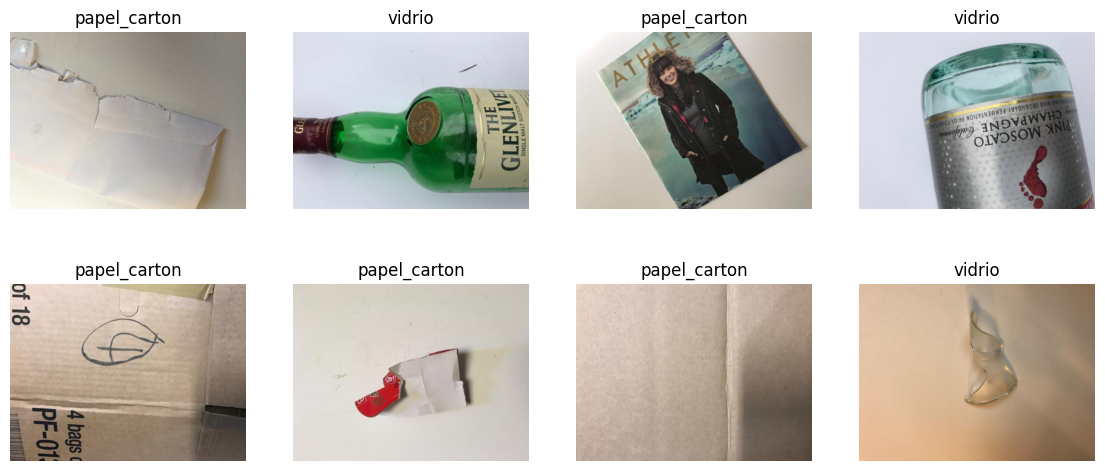

In [6]:
def mostrar_muestras_clasificacion(dataset_dir, split='train', n=8):
    imgs = list((dataset_dir / split).rglob('*.jpg')) + list((dataset_dir / split).rglob('*.png'))
    imgs = random.sample(imgs, min(n, len(imgs)))

    plt.figure(figsize=(14, 6))
    for i, img_path in enumerate(imgs, 1):
        img = Image.open(img_path).convert('RGB')
        plt.subplot(2, 4, i)
        plt.imshow(img)
        plt.title(img_path.parent.name)
        plt.axis('off')
    plt.show()

mostrar_muestras_clasificacion(CLS_DIR, split='train', n=8)

# 6. Entrenamiento del modelo de clasificación

Esta sección entrena un modelo YOLO para clasificar residuos.

## Explicación

El modelo observará las imágenes de entrenamiento y aprenderá patrones visuales de cada clase.

Por ejemplo:

- Las botellas de plástico suelen tener cierta forma y textura.
- El cartón suele tener colores y bordes diferentes.
- Las latas suelen reflejar más luz.

## Instrucción

Ejecuta la celda. Esta parte puede tardar varios minutos.

## Resultado esperado

Al finalizar, YOLO guardará el mejor modelo en una ruta parecida a:

```text
/content/yolo_residuos/runs/clasificacion_residuos/weights/best.pt
```

In [7]:
modelo_cls = YOLO(MODEL_CLS)

resultados_cls = modelo_cls.train(
    data=str(CLS_DIR),
    epochs=EPOCHS_CLS,
    imgsz=IMG_SIZE_CLS,
    seed=SEED,
    project=str(BASE_DIR / 'runs'),
    name='clasificacion_residuos',
    exist_ok=True
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_residuos/dataset_clasificacion_yolo, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=clasificacion_residuos, nbs=64, nms=False, opset=None, optimize=False, optimize

# 7. Prueba del modelo de clasificación

Enseguida se elige una imagen del conjunto de prueba y usa el modelo entrenado para predecir su clase.

## Instrucción

Ejecuta la celda después de haber entrenado el modelo.

## Resultado esperado

El modelo debe mostrar la clase predicha y guardar una imagen o resultado dentro de la carpeta `runs`.

In [8]:
BEST_CLS = BASE_DIR / 'runs' / 'clasificacion_residuos' / 'weights' / 'best.pt'
modelo_cls_entrenado = YOLO(str(BEST_CLS))

imagenes_test_cls = list((CLS_DIR / 'test').rglob('*.jpg')) + list((CLS_DIR / 'test').rglob('*.png'))
#img_prueba_cls = random.choice(imagenes_test_cls)
img_prueba_cls = "/content/tu_imagen.jpg"
print('Imagen de prueba:', img_prueba_cls)
#print('Clase real según la carpeta:', img_prueba_cls.parent.name)

pred_cls = modelo_cls_entrenado.predict(source=str(img_prueba_cls), save=True)

Imagen de prueba: /content/tu_imagen.jpg

image 1/1 /content/tu_imagen.jpg: 224x224 plastico 0.93, papel_carton 0.07, basura_general 0.00, metal 0.00, vidrio 0.00, 4.6ms
Speed: 13.2ms preprocess, 4.6ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to /content/runs/classify/predict


# Parte B. Segmentación con TACO

Ahora entrenaremos un modelo que no solo diga qué residuo aparece, sino que también dibuje una máscara sobre el objeto.

## Diferencia con clasificación

En clasificación, el modelo responde:

```text
Esta imagen es plastico.
```

En segmentación, el modelo responde:

```text
Aquí está el objeto plastico y esta es su forma exacta dentro de la imagen.
```

## Dataset usado

Usaremos **TACO — Trash Annotations in Context**, un dataset gratuito con imágenes de residuos en ambientes reales.

## Importante

TACO tiene muchas categorías. En este notebook se agrupan en cinco clases generales:

| Clase final | Qué incluye aproximadamente |
|---|---|
| plastico | botellas, tapas, vasos, envolturas, popotes, unicel |
| papel_carton | papel, cartón, servilletas, vasos de papel |
| metal | latas, aluminio, tapas metálicas |
| vidrio | botellas o fragmentos de vidrio |
| basura_general | residuos que no entran claramente en las otras clases |

# 8. Descarga de TACO

Esta sección descarga y descomprime el dataset TACO.

## Instrucción

Ejecuta la celda. El archivo puede ser más pesado que TrashNet, así que puede tardar más.

## Resultado esperado

Debe aparecer una lista de archivos `.json`, porque TACO trae anotaciones en formato COCO.

In [9]:
TACO_ZIP = BASE_DIR / 'TACO.zip'
TACO_RAW = BASE_DIR / 'TACO_raw'

if not TACO_ZIP.exists():
    print('Descargando TACO...')
    !wget -q -O {TACO_ZIP} "https://zenodo.org/records/3354286/files/TACO.zip?download=1"
else:
    print('TACO ya estaba descargado.')

if not TACO_RAW.exists():
    print('Descomprimiendo TACO...')
    TACO_RAW.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(TACO_ZIP, 'r') as z:
        z.extractall(TACO_RAW)
else:
    print('TACO ya estaba descomprimido.')

annotation_files = list(TACO_RAW.rglob('annotations.json')) + list(TACO_RAW.rglob('*.json'))
print('Archivos JSON encontrados:')
for p in annotation_files[:10]:
    print(p)

Descargando TACO...
Descomprimiendo TACO...
Archivos JSON encontrados:
/content/yolo_residuos/TACO_raw/TACO/data/annotations.json
/content/yolo_residuos/TACO_raw/TACO/data/batch_2/annotations.json
/content/yolo_residuos/TACO_raw/TACO/data/batch_5/annotations.json
/content/yolo_residuos/TACO_raw/TACO/data/batch_4/annotations.json
/content/yolo_residuos/TACO_raw/TACO/data/batch_6/annotations.json
/content/yolo_residuos/TACO_raw/TACO/data/batch_7/annotations.json
/content/yolo_residuos/TACO_raw/TACO/data/batch_3/annotations.json
/content/yolo_residuos/TACO_raw/TACO/data/batch_1/annotations.json
/content/yolo_residuos/TACO_raw/TACO/data/annotations.json
/content/yolo_residuos/TACO_raw/TACO/data/batch_2/annotations.json


# 9. Conversión de TACO a formato YOLO segmentación

TACO viene en formato COCO, pero YOLO necesita otro formato para segmentación.

Esta celda convierte las anotaciones para que queden así:

```text
clase x1 y1 x2 y2 x3 y3 ... xn yn
```

## Explicación

- `clase` es el número de la categoría.
- `x1 y1 x2 y2...` son puntos que forman el contorno del objeto.
- Las coordenadas se normalizan entre 0 y 1.

## Instrucción

Ejecutar la celda, puede tardar porque copia imágenes y crea etiquetas.

## Resultado esperado

Se creará una carpeta llamada:

```text
dataset_segmentacion_yolo
```

con subcarpetas de imágenes y etiquetas.

In [ ]:
SEG_DIR = BASE_DIR / 'dataset_segmentacion_yolo'

names_seg = ['plastico', 'papel_carton', 'metal', 'vidrio', 'basura_general']
name_to_id = {name: i for i, name in enumerate(names_seg)}

# Selecciona el archivo JSON más probable.
json_candidates = [p for p in TACO_RAW.rglob('annotations.json')]
if not json_candidates:
    json_candidates = [p for p in TACO_RAW.rglob('*.json')]

if not json_candidates:
    raise FileNotFoundError('No se encontró un archivo JSON de anotaciones en TACO.')

ANN_PATH = json_candidates[0]
print('Archivo de anotaciones:', ANN_PATH)

with open(ANN_PATH, 'r', encoding='utf-8') as f:
    coco = json.load(f)

categories = {cat['id']: cat for cat in coco['categories']}
images = {img['id']: img for img in coco['images']}
anns_by_img = defaultdict(list)

for ann in coco['annotations']:
    anns_by_img[ann['image_id']].append(ann)


def mapear_categoria_taco(cat):
    """Agrupa categorías específicas de TACO en clases generales del ejercicio."""
    text = (cat.get('name', '') + ' ' + cat.get('supercategory', '')).lower()

    if any(k in text for k in [
        'plastic', 'styrofoam', 'straw', 'wrapper', 'lid', 'cup',
        'single-use carrier bag', 'blister', 'polypropylene'
    ]):
        return 'plastico'

    if any(k in text for k in [
        'paper', 'carton', 'cardboard', 'tissue', 'newspaper'
    ]):
        return 'papel_carton'

    if any(k in text for k in [
        'metal', 'aluminium', 'aluminum', 'can', 'foil', 'pop tab'
    ]):
        return 'metal'

    if 'glass' in text:
        return 'vidrio'

    return 'basura_general'


def encontrar_imagen_taco(file_name):
    """Busca una imagen de TACO aunque el ZIP tenga carpetas internas distintas."""
    direct = TACO_RAW / file_name
    if direct.exists():
        return direct

    matches = list(TACO_RAW.rglob(file_name))
    if matches:
        return matches[0]

    fname = Path(file_name).name
    matches = list(TACO_RAW.rglob(fname))
    if matches:
        return matches[0]

    return None


def normalizar_poligono(poly, width, height):
    """Convierte coordenadas absolutas de píxeles a coordenadas entre 0 y 1."""
    coords = []
    for i in range(0, len(poly), 2):
        x = min(max(poly[i] / width, 0), 1)
        y = min(max(poly[i+1] / height, 0), 1)
        coords.extend([x, y])
    return coords

# Si ya existía una versión preparada, se borra para crearla de nuevo.
if SEG_DIR.exists():
    shutil.rmtree(SEG_DIR)

for split in ['train', 'val', 'test']:
    (SEG_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (SEG_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

# Filtrar imágenes con al menos una anotación poligonal válida.
valid_img_ids = []

for img_id, img in images.items():
    anns = anns_by_img.get(img_id, [])
    tiene_poligono = False

    for ann in anns:
        seg = ann.get('segmentation', [])
        if isinstance(seg, list) and any(isinstance(poly, list) and len(poly) >= 6 for poly in seg):
            tiene_poligono = True
            break

    if tiene_poligono and encontrar_imagen_taco(img['file_name']) is not None:
        valid_img_ids.append(img_id)

random.shuffle(valid_img_ids)

if MAX_IMAGES_SEG is not None:
    valid_img_ids = valid_img_ids[:MAX_IMAGES_SEG]

n = len(valid_img_ids)
n_train = int(n * 0.70)
n_val = int(n * 0.20)

splits_seg = {
    'train': valid_img_ids[:n_train],
    'val': valid_img_ids[n_train:n_train+n_val],
    'test': valid_img_ids[n_train+n_val:]
}

conteo_clases_seg = Counter()
conteo_imgs_seg = {}

for split, img_ids in splits_seg.items():
    conteo_imgs_seg[split] = len(img_ids)

    for img_id in tqdm(img_ids, desc=f'Convirtiendo {split}'):
        img_info = images[img_id]
        src_img = encontrar_imagen_taco(img_info['file_name'])

        if src_img is None:
            continue

        width = img_info.get('width')
        height = img_info.get('height')

        if width is None or height is None:
            with Image.open(src_img) as im:
                width, height = im.size

        out_img_name = f"{img_id}_{Path(src_img).name}"
        dst_img = SEG_DIR / 'images' / split / out_img_name
        shutil.copy2(src_img, dst_img)

        label_lines = []

        for ann in anns_by_img.get(img_id, []):
            if ann.get('iscrowd', 0) == 1:
                continue

            seg = ann.get('segmentation', [])
            if not isinstance(seg, list):
                continue

            cat = categories[ann['category_id']]
            mapped_name = mapear_categoria_taco(cat)
            cls_id = name_to_id[mapped_name]

            for poly in seg:
                if not isinstance(poly, list) or len(poly) < 6:
                    continue

                coords = normalizar_poligono(poly, width, height)
                if len(coords) < 6:
                    continue

                line = str(cls_id) + ' ' + ' '.join(f'{v:.6f}' for v in coords)
                label_lines.append(line)
                conteo_clases_seg[mapped_name] += 1

        label_path = SEG_DIR / 'labels' / split / (Path(out_img_name).stem + '.txt')
        with open(label_path, 'w', encoding='utf-8') as f:
            f.write('\n'.join(label_lines))

# Crear archivo data.yaml para YOLO segmentación.
seg_yaml = {
    'path': str(SEG_DIR),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {i: name for i, name in enumerate(names_seg)}
}

SEG_YAML = SEG_DIR / 'data.yaml'
with open(SEG_YAML, 'w', encoding='utf-8') as f:
    yaml.safe_dump(seg_yaml, f, sort_keys=False, allow_unicode=True)

print('Dataset de segmentación creado en:', SEG_DIR)
print('Imágenes por conjunto:', conteo_imgs_seg)
print('Objetos por clase:', conteo_clases_seg)
print('Archivo YAML:', SEG_YAML)

# 10. Visualización de imágenes de segmentación

Esta sección muestra algunas imágenes del dataset de segmentación ya preparado.

Ejecuta la celda para revisar ejemplos de las imágenes que se usarán en el entrenamiento.

Como resultado deben aparecer imágenes reales con residuos en distintos fondos.

In [ ]:
def mostrar_muestras_segmentacion(dataset_dir, split='train', n=6):
    imgs = list((dataset_dir / 'images' / split).rglob('*.jpg')) + list((dataset_dir / 'images' / split).rglob('*.png'))
    imgs = random.sample(imgs, min(n, len(imgs)))

    plt.figure(figsize=(14, 8))
    for i, img_path in enumerate(imgs, 1):
        img = Image.open(img_path).convert('RGB')
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis('off')
    plt.show()

mostrar_muestras_segmentacion(SEG_DIR, split='train', n=6)

# 11. Entrenamiento del modelo de segmentación

Esta sección entrena un modelo YOLO para segmentar residuos.

## Explicación

Este modelo aprende a detectar objetos y a marcar su forma mediante máscaras.

Es una tarea más difícil que clasificación porque el modelo debe aprender:

- qué objeto aparece,
- dónde está,
- cuál es su contorno o forma.

Ejecuta la celda después de preparar el dataset de segmentación.

## Resultado esperado

YOLO guardará el mejor modelo en una ruta parecida a:

```text
/content/yolo_residuos/runs/segmentacion_residuos/weights/best.pt
```

In [12]:
modelo_seg = YOLO(MODEL_SEG)

resultados_seg = modelo_seg.train(
    data=str(SEG_YAML),
    epochs=EPOCHS_SEG,
    imgsz=IMG_SIZE_SEG,
    seed=SEED,
    project=str(BASE_DIR / 'runs'),
    name='segmentacion_residuos',
    exist_ok=True
)

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_residuos/dataset_segmentacion_yolo/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=segmentacion_residuos, nbs=64, nms=False, opset=None, optimize=False, 

# 12. Prueba del modelo de segmentación

Esta sección selecciona una imagen de prueba y usa el modelo entrenado para segmentar los residuos.

## Instrucción

Ejecuta la celda después de entrenar el modelo de segmentación.

Posteriormente YOLO debe generar una imagen donde los residuos aparezcan marcados con máscaras.

In [13]:
BEST_SEG = BASE_DIR / 'runs' / 'segmentacion_residuos' / 'weights' / 'best.pt'
modelo_seg_entrenado = YOLO(str(BEST_SEG))

imagenes_test_seg = list((SEG_DIR / 'images' / 'test').rglob('*.jpg')) + list((SEG_DIR / 'images' / 'test').rglob('*.png'))
#img_prueba_seg = random.choice(imagenes_test_seg)
img_prueba_seg = "/content/tu_imagen.jpg"
print('Imagen de prueba:', img_prueba_seg)

pred_seg = modelo_seg_entrenado.predict(source=str(img_prueba_seg), save=True, conf=0.25)

Imagen de prueba: /content/tu_imagen.jpg

image 1/1 /content/tu_imagen.jpg: 480x640 9 plasticos, 1 metal, 64.6ms
Speed: 2.7ms preprocess, 64.6ms inference, 10.5ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/segment/predict


# Parte C. Comparación entre clasificación y segmentación

Después de entrenar y probar ambos modelos, contesta lo siguiente:

| Pregunta | Respuesta esperada |
|---|---|
| ¿Qué modelo fue más fácil de preparar? | Normalmente clasificación, porque solo requiere carpetas por clase. |
| ¿Qué modelo fue más difícil? | Segmentación, porque necesita máscaras o polígonos. |
| ¿Cuál modelo da más información? | Segmentación, porque dice clase, ubicación y forma. |
| ¿Qué pasa si hay varios objetos? | Clasificación puede confundirse; segmentación puede detectar varios objetos. |
| ¿Cuál sirve más para un contenedor inteligente? | Segmentación, porque permite separar objetos y conocer su posición. |

## Conclusión

El modelo de clasificación es útil cuando la imagen contiene un residuo principal y se quiere una respuesta rápida. Sin embargo, el modelo de segmentación es más completo porque permite ubicar cada residuo y marcar su forma. Para aplicaciones reales, como un contenedor inteligente, un robot recolector o un sistema automatizado de reciclaje, la segmentación resulta más útil, aunque requiere más trabajo de etiquetado.

# Para entregar la práctica, incluir:

1. Captura del dataset de clasificación organizado en carpetas.
2. Captura del dataset de segmentación con imágenes y etiquetas.
3. Captura del entrenamiento del modelo de clasificación.
4. Captura del entrenamiento del modelo de segmentación.
5. Pruebas con imágenes nuevas.
6. Tabla comparativa entre clasificación y segmentación.
7. Conclusión personal sobre qué modelo fue más útil y por qué.

## Ejemplo de tabla comparativa para incluir en el Reporte

| Aspecto | Clasificación | Segmentación |
|---|---|---|
| Entrada | Imagen completa | Imagen con objetos |
| Salida | Una clase general | Clase, ubicación y máscara |
| Dificultad del dataset | Baja | Alta |
| Utilidad en imágenes con varios residuos | Limitada | Alta |
| Aplicación recomendada | Clasificación rápida | Separación inteligente de residuos |

# Problemas comunes y posibls soluciones

## 1. El entrenamiento tarda mucho

Baja estos valores en la sección de configuración:

```python
EPOCHS_CLS = 5
EPOCHS_SEG = 10
MAX_IMAGES_SEG = 300
```

## 2. No se descarga el dataset

Vuelve a ejecutar la celda de descarga. También puedes revisar si Colab perdió conexión a internet.

## 3. El modelo no predice bien

Puede deberse a pocas épocas de entrenamiento, clases desbalanceadas o imágenes difíciles.

## 4. La segmentación se ve menos precisa que la clasificación

Es normal. Segmentar es más complejo porque el modelo debe aprender la forma del objeto, no solo su clase.

## 5. Quiero agregar la clase orgánico

Puedes crear una nueva carpeta `organico` en clasificación y agregar imágenes propias. Para segmentación, necesitarías imágenes con máscaras de objetos orgánicos, como cáscaras o restos de comida.

## Tarea para completar el reporte del Ejercicio:

Incorpora métricas para validar los resultados, señalándo por qué es importante considerarlas.
Describe el análisis de las métricas propuestas.

Comparación entre clasificación y segmentación

Después de entrenar y probar los dos modelos, estas son mis observaciones:

| Pregunta | Mi respuesta |
|---|---|
| ¿Qué modelo fue más fácil de preparar? | El de clasificación, porque solo tuve que organizar las fotos en carpetas por tipo de basura. |
| ¿Qué modelo fue más difícil? | El de segmentación, porque necesitaba convertir las anotaciones de TACO a un formato diferente y tardó más en entrenar. |
| ¿Cuál modelo da más información? | El de segmentación, porque no solo dice qué es el residuo sino que también marca exactamente dónde está y cuál es su forma. |
| ¿Qué pasa si hay varios objetos en la imagen? | El de clasificación puede confundirse, pero el de segmentación detecta y separa cada objeto sin problema. |
| ¿Cuál sirve más para un contenedor inteligente? | El de segmentación, porque necesitas saber dónde está cada residuo para poder separarlo físicamente. |

# Conclusión

Con esta práctica aprendí la diferencia entre clasificar y segmentar imágenes usando YOLO.

El modelo de **clasificación** fue más sencillo de hacer y funcionó muy bien, llegando a un 93.2% de precisión. Básicamente le muestras una foto y te dice qué tipo de basura es. El problema es que si en la foto hay varios tipos de residuos al mismo tiempo, puede confundirse.

El modelo de **segmentación** fue más complicado de preparar porque necesitaba que las imágenes tuvieran marcado exactamente dónde estaba cada objeto. También tardó más en entrenar. Pero el resultado es mucho más completo: no solo identifica qué es la basura, sino que dibuja su contorno exacto en la imagen.

Si tuviera que elegir uno para una aplicación real, como un contenedor inteligente o un robot que separe basura, elegiría el de **segmentación**. Aunque es más difícil de entrenar, es el único que te da la información suficiente para saber qué residuo es, dónde está y cómo agarrarlo o separarlo.

Para mejorar los modelos en el futuro, conseguiría más imágenes de las clases con menos ejemplos, especialmente vidrio, que fue la clase donde el modelo tuvo más dificultades.